In [5]:
# ==============================================================================
# CELULA 1: CONFIGURACAO DE AMBIENTE E HARDWARE (LOCAL)
# ==============================================================================
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from typing import Tuple, Any

import deepwave
from deepwave import scalar

# Verificacao de Hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Sistema] Executando localmente. Dispositivo mapeado: {device}")

[Sistema] Executando localmente. Dispositivo mapeado: cuda


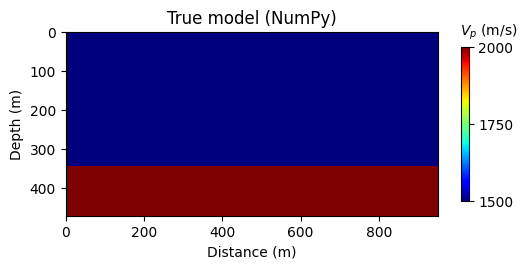

In [6]:
# ==============================================================================
# CELULA 2: CONSTRUCAO E VISUALIZACAO DO MODELO EM NUMPY
# ==============================================================================
# Definicoes das dimensoes do modelo
ny = 96
nz = 48
oz = 0.0
oy = 0.0
dz = 10.0
dy = 10.0

# Construcao dos vetores de profundidade (z) e distancia (y)
z_values = np.arange(oz, oz + nz * dz, dz)
y_values = np.arange(oy, oy + ny * dy, dy)

layer_01 = 1500.0
layer_02 = 2000.0

# Criacao do modelo homogeneo em NumPy
model = (np.ones((nz, ny)) * layer_01).astype(np.float32)

# Adicionando a segunda camada (refletor)
model[35:, :] = layer_02

# Obtencao dos valores maximos e minimos para escala de cor
maxval = np.max(model)
minval = np.min(model)

# Plotagem do modelo original (NumPy)
plt.figure(figsize=(6, 4))
plt.imshow(model, cmap='jet', extent=[y_values[0], y_values[-1], z_values[-1], z_values[0]])
plt.clim(vmin=minval, vmax=maxval)

cbar = plt.colorbar(shrink=0.5)
cbar.ax.tick_params(labelsize=10)
tick_values = np.arange(minval, maxval + 1, 250)
cbar.set_ticks(tick_values)

plt.title('True model (NumPy)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
cbar.set_label(r'$V_p$ (m/s)', labelpad=-18, y=1.16, rotation=0)
plt.show()

NumPy model shape : (48, 96)
Torch model shape : torch.Size([96, 48])


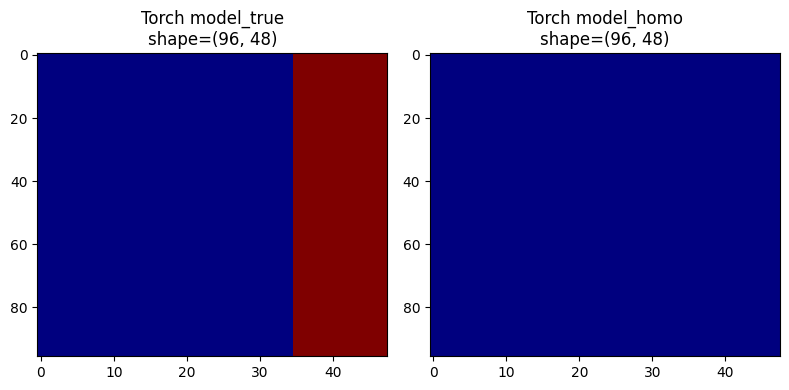

In [7]:
# ==============================================================================
# CELULA 3: CONVERSAO PARA TENSORES PYTORCH E COMPARACOES
# ==============================================================================
print(f"NumPy model shape : {model.shape}")

# Criacao do tensor do modelo verdadeiro e movimentacao para GPU
model_true = torch.tensor(model, dtype=torch.float32, device=device).T

# Criacao do modelo homogeneo (background) para a inversao inicial
model_homo = (torch.ones(ny, nz, device=device))
model_homo = model_homo * (layer_01 - 100) # Modelo com velocidade propositalmente errada

print(f"Torch model shape : {model_true.shape}")

# Plotagem comparativa
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(model_true.cpu(), aspect='auto', cmap='jet')
plt.title(f"Torch model_true\nshape={tuple(model_true.shape)}")

plt.subplot(1, 2, 2)
plt.imshow(model_homo.cpu(), aspect='auto', cmap='jet')
plt.title(f"Torch model_homo\nshape={tuple(model_homo.shape)}")

plt.tight_layout()
plt.show()

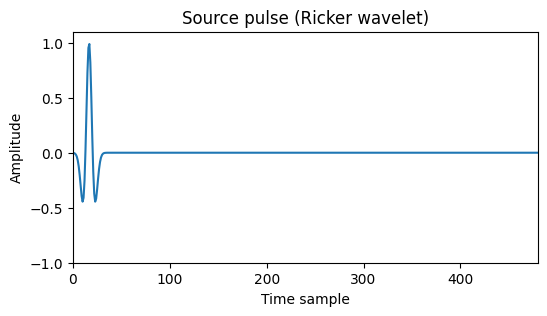

In [10]:
# ==============================================================================
# CELULA 4: PARAMETROS DO DEEPWAVE E GEOMETRIA DE AQUISICAO
# ==============================================================================
dx = 10.0
dt = 0.004
nt = 480
peak_freq = 15
peak_source_time = 1 / peak_freq
peak_time = 1.0 / peak_freq

num_dims = 2
num_shots = 1
num_sources_per_shot = 1
num_receivers_per_shot = 1
source_spacing = 1
receiver_spacing = 1
first_source = 20
first_receiver = 76
source_depth = 10
receiver_depth = 10

# Configuracao de Fontes
source_locations = torch.zeros(num_shots, num_sources_per_shot, 2, dtype=torch.long, device=device)
source_locations[..., 1] = source_depth
source_locations[:, 0, 0] = torch.arange(num_shots) * source_spacing + first_source

# Configuracao de Receptores
receiver_locations = torch.zeros(num_shots, num_receivers_per_shot, 2, dtype=torch.long, device=device)
receiver_locations[..., 1] = receiver_depth
receiver_locations[:, :, 0] = ((torch.arange(num_receivers_per_shot) * receiver_spacing + first_receiver).repeat(num_shots, 1))

# Geracao do pulso da fonte (Wavelet de Ricker)
source_amplitudes = (
    deepwave.wavelets.ricker(peak_freq, nt, dt, peak_time)
    .repeat(num_shots, num_sources_per_shot, 1)
    .to(device)
)

# Plotagem do pulso da fonte (Corrigido para reducao dimensional via squeeze)
plt.figure(figsize=(6, 3))
plt.plot(source_amplitudes.cpu().squeeze().numpy())
plt.ylim(-1, 1 + 0.1)
plt.xlim(0, nt)
plt.title('Source pulse (Ricker wavelet)')
plt.ylabel('Amplitude')
plt.xlabel('Time sample')
plt.show()

[Modelagem] Propagando no modelo verdadeiro...
[Modelagem] Propagando no modelo homogeneo (background)...
Formato do Residuo: torch.Size([1, 1, 480])
Central shot index: 0


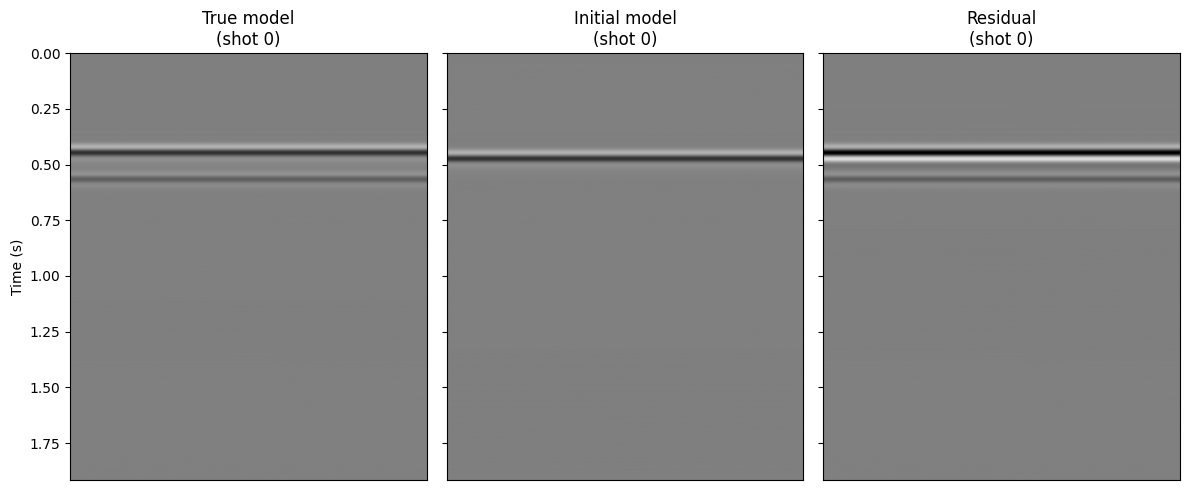

In [11]:
# ==============================================================================
# CELULA 5: MODELAGEM DIRETA (TRUE E HOMO) E CALCULO DO RESIDUO
# ==============================================================================
print("[Modelagem] Propagando no modelo verdadeiro...")
out_true = scalar(
    model_true, dx, dt, max_vel=2500.0,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8,
    pml_freq=peak_freq, pml_width=[30, 30, 30, 30]
)
receiver_amplitudes_true = out_true[-1]

print("[Modelagem] Propagando no modelo homogeneo (background)...")
out_homo = scalar(
    model_homo, dx, dt, max_vel=2500.0,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8,
    pml_freq=peak_freq, pml_width=[30, 30, 30, 30]
)
receiver_amplitudes_homo = out_homo[-1]

# Calculo do residuo dos dados
residual = receiver_amplitudes_true - receiver_amplitudes_homo
print(f"Formato do Residuo: {residual.shape}")

# Extracao de um traco para o tiro central
ishot = num_shots // 2
print(f"Central shot index: {ishot}")

time_vec = np.arange(nt) * dt
trace_true = receiver_amplitudes_true[ishot].detach().cpu().mT
trace_homo = receiver_amplitudes_homo[ishot].detach().cpu().mT
trace_res  = residual[ishot].detach().cpu().mT

# Escala de cores comum baseada no maximo absoluto
vmax_trace = max(
    float(torch.max(torch.abs(trace_true))),
    float(torch.max(torch.abs(trace_homo))),
    float(torch.max(torch.abs(trace_res)))
)
vmin_trace = -vmax_trace

# Plotagem dos Sismogramas (True, Initial, Residual)
fig, ax = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

ax[0].imshow(trace_true.numpy(), aspect='auto', cmap='gray', vmin=vmin_trace, vmax=vmax_trace, extent=[0, 1, time_vec[-1], time_vec[0]])
ax[0].set_title(f"True model\n(shot {ishot})")
ax[0].set_ylabel("Time (s)")
ax[0].set_xticks([])

ax[1].imshow(trace_homo.numpy(), aspect='auto', cmap='gray', vmin=vmin_trace, vmax=vmax_trace, extent=[0, 1, time_vec[-1], time_vec[0]])
ax[1].set_title(f"Initial model\n(shot {ishot})")
ax[1].set_xticks([])

ax[2].imshow(trace_res.numpy(), aspect='auto', cmap='gray', vmin=vmin_trace, vmax=vmax_trace, extent=[0, 1, time_vec[-1], time_vec[0]])
ax[2].set_title(f"Residual\n(shot {ishot})")
ax[2].set_xticks([])

plt.tight_layout()
plt.show()

Loss value: 0.37496793270111084
Min Grad: -1.5819412510609254e-05, Max Grad: 1.5819412510609254e-05


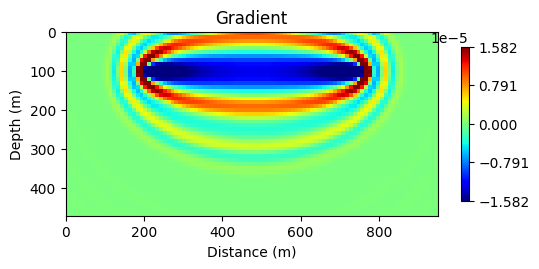

In [12]:
# ==============================================================================
# CELULA 6: CALCULO DE GRADIENTE ISOLADO (AUTOGRAD)
# ==============================================================================
def gradient_DW(model_input: torch.Tensor) -> Tuple[np.ndarray, float]:
    """Calcula o gradiente usando o solver Deepwave e o Autograd do PyTorch."""
    vel = model_input.clone().detach().to(device).requires_grad_(True)
    objfun = torch.nn.MSELoss()

    out = scalar(
        vel, dx, dt, max_vel=2500.0,
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        accuracy=8,
        pml_freq=peak_freq, pml_width=[30, 30, 30, 30]
    )

    loss = objfun(out[-1], receiver_amplitudes_true)
    loss.backward()
    
    # Recorte de gradiente por magnitude
    clip_val = torch.quantile(vel.grad.detach().abs(), 0.98)
    torch.nn.utils.clip_grad_value_(vel, clip_val)

    return vel.grad.detach().cpu().numpy().T, loss.item()

grad, loss_val = gradient_DW(model_homo)
print(f"Loss value: {loss_val}")

maxval_g = np.max(grad)
minval_g = np.min(grad)
print(f"Min Grad: {minval_g}, Max Grad: {maxval_g}")

plt.figure(figsize=(6, 4))
plt.imshow(grad, cmap='jet', extent=[y_values[0], y_values[-1], z_values[-1], z_values[0]])
plt.clim(vmin=minval_g, vmax=maxval_g)

cbar = plt.colorbar(shrink=0.5)
cbar.ax.tick_params(labelsize=10)
cbar.set_ticks(np.arange(minval_g, maxval_g + maxval_g*0.01, (maxval_g - minval_g)/4))
plt.title('Gradient')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.show()

In [13]:
# ==============================================================================
# CELULA 7: PREPARACAO DOS CALLBACKS PARA SNAPSHOTS
# ==============================================================================
callback_frequency = 1

# Buffers de armazenamento
forward_snapshots = torch.zeros(nt // callback_frequency, ny, nz)
backward_snapshots = torch.zeros(nt // callback_frequency, ny, nz)
gradient_snapshots = torch.zeros(nt // callback_frequency, ny, nz)

class ForwardCallback:
    """Callback para armazenar snapshots durante a propagacao direta."""
    def __init__(self, ishot: int):
        self.ishot = ishot
        self.step = 0

    def __call__(self, state: Any) -> None:
        forward_snapshots[self.step] = state.get_wavefield("wavefield_0")[self.ishot].cpu().clone()
        self.step += 1

class BackwardCallback:
    """Callback para armazenar snapshots durante a retropropagacao."""
    def __init__(self, ishot: int):
        self.ishot = ishot
        self.step = 0

    def __call__(self, state: Any) -> None:
        backward_snapshots[self.step] = state.get_wavefield("wavefield_0")[self.ishot].cpu().clone()
        gradient_snapshots[self.step] = state.get_gradient("v")[0].cpu().clone()
        self.step += 1

[Animacao] Rodando propagacao completa no modelo verdadeiro...


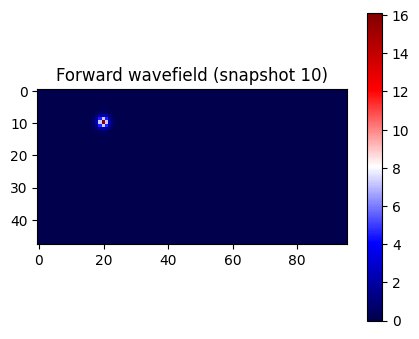

In [14]:
# ==============================================================================
# CELULA 8: PROPAGACAO DIRETA, EXTRACAO HTML E SNAPSHOT ESTATICO
# ==============================================================================
print("[Animacao] Rodando propagacao completa no modelo verdadeiro...")
vmodel_true = model_true.clone().requires_grad_(True)
vmax_true = model_true.max().item()
ctrl_shot = num_shots // 2

out_fwd = scalar(
    vmodel_true, dx, dt, max_vel=vmax_true,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8, pml_freq=peak_freq, pml_width=[30, 30, 30, 30],
    forward_callback=ForwardCallback(ishot=ctrl_shot),
    callback_frequency=callback_frequency
)
data_true = out_fwd[-1]

# Compilando Animacao HTML do Forward
vmax_fwd_anim = torch.quantile(forward_snapshots, 0.99).item()
fig_anim, ax_anim = plt.subplots(figsize=(5, 4))
im_anim = ax_anim.imshow(forward_snapshots[1].T, vmax=vmax_fwd_anim, cmap="seismic", animated=True)
ax_anim.set_xticks([])
ax_anim.set_yticks([])
title_anim = ax_anim.set_title("Forward (t = 0.000 s)")
plt.close(fig_anim)

def update_fwd(frame):
    im_anim.set_data(forward_snapshots[frame].T)
    t = frame * callback_frequency * dt
    title_anim.set_text(f"Forward (t = {t:.3f} s)")
    return (im_anim, title_anim)

ani_fwd = animation.FuncAnimation(fig_anim, update_fwd, frames=len(forward_snapshots), interval=25, blit=True)
display(HTML(ani_fwd.to_jshtml()))

# Visualizacao estatica de um snapshot especifico
snap_idx = 10
plt.figure(figsize=(5, 4))
plt.imshow(forward_snapshots[snap_idx].T, cmap="seismic")
plt.colorbar()
plt.title(f"Forward wavefield (snapshot {snap_idx})")
plt.show()

[Adjoint State] Rodando propagacao reversa no modelo homogeneo...


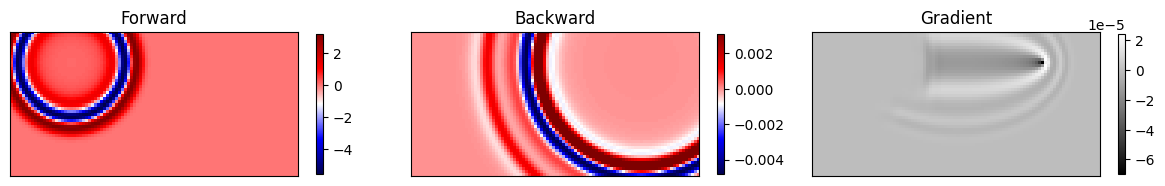

In [15]:
# ==============================================================================
# CELULA 9: METODO DO ESTADO ADJUNTO (BACKWARD PASS) E ANIMACAO COMPLETA
# ==============================================================================
print("[Adjoint State] Rodando propagacao reversa no modelo homogeneo...")
vmodel_homo = model_homo.clone().requires_grad_(True)
out_adj = scalar(
    vmodel_homo, dx, dt, max_vel=vmax_true,
    source_amplitudes=source_amplitudes,
    source_locations=source_locations,
    receiver_locations=receiver_locations,
    accuracy=8, pml_freq=peak_freq, pml_width=[30, 30, 30, 30],
    forward_callback=ForwardCallback(ishot=ctrl_shot),
    backward_callback=BackwardCallback(ishot=ctrl_shot),
    callback_frequency=callback_frequency
)
data_adj = out_adj[-1]

# Injetando o residuo retrogradamente
torch.nn.MSELoss()(data_true, data_adj).backward()

# Visualizacao estatica do Estado Adjunto (Passo 50)
snap_adj = 50
vmax_fwd_s = torch.quantile(forward_snapshots[snap_adj], 0.99).item()
vmax_bwd_s = vmax_fwd_s * 1e-3
vmax_grad_s = torch.quantile(gradient_snapshots[snap_adj].abs(), 1.0).item()

fig_adj, axes_adj = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

im0_adj = axes_adj[0].imshow(forward_snapshots[snap_adj].T, cmap="seismic")
axes_adj[0].set_title("Forward")

im1_adj = axes_adj[1].imshow(backward_snapshots[nt - snap_adj].T, cmap="seismic", vmax=vmax_bwd_s)
axes_adj[1].set_title("Backward")

im2_adj = axes_adj[2].imshow(gradient_snapshots[nt - snap_adj].T, cmap="gray")
axes_adj[2].set_title("Gradient")

for ax in axes_adj:
    ax.set_xticks([])
    ax.set_yticks([])

fig_adj.colorbar(im0_adj, ax=axes_adj[0], shrink=0.38)
fig_adj.colorbar(im1_adj, ax=axes_adj[1], shrink=0.38)
fig_adj.colorbar(im2_adj, ax=axes_adj[2], shrink=0.38)
plt.tight_layout()
plt.show()

In [16]:
# ==============================================================================
# CELULA 10: ANIMACAO HTML FINAL (FORWARD, BACKWARD, GRADIENT)
# ==============================================================================
print("[Animacao Final] Compilando video do Estado Adjunto completo...")
frame_step = 10
interval_ms = 120
nframes_total = min(len(forward_snapshots), len(backward_snapshots), len(gradient_snapshots))

frames = list(range(0, nframes_total, frame_step))
if frames[-1] != nframes_total - 1:
    frames.append(nframes_total - 1)

vmax_fwd_all = torch.quantile(forward_snapshots, 0.99).item()
vmax_bwd_all = vmax_fwd_all * 1e-3
vmax_grad_all = torch.quantile(gradient_snapshots.abs(), 0.99).item()

fig_all, axes_all = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

im0_all = axes_all[0].imshow(forward_snapshots[0].T, cmap="seismic", vmin=-vmax_fwd_all, vmax=vmax_fwd_all, animated=True)
im1_all = axes_all[1].imshow(backward_snapshots[0].T, cmap="seismic", vmin=-vmax_bwd_all, vmax=vmax_bwd_all, animated=True)
im2_all = axes_all[2].imshow(gradient_snapshots[0].T, cmap="gray", vmin=-vmax_grad_all, vmax=vmax_grad_all, animated=True)

for ax in axes_all:
    ax.set_xticks([])
    ax.set_yticks([])

titles_all = [
    axes_all[0].set_title("Forward"),
    axes_all[1].set_title("Backward"),
    axes_all[2].set_title("Gradient"),
]

fig_all.colorbar(im0_all, ax=axes_all[0], shrink=0.8)
fig_all.colorbar(im1_all, ax=axes_all[1], shrink=0.8)
fig_all.colorbar(im2_all, ax=axes_all[2], shrink=0.8)
plt.tight_layout()
plt.close(fig_all)

def update_all(frame):
    im0_all.set_data(forward_snapshots[nframes_total - 1 - frame].T)
    im1_all.set_data(backward_snapshots[frame].T)
    im2_all.set_data(gradient_snapshots[frame].T)

    t = (nframes_total - 1 - frame) * callback_frequency * dt
    titles_all[0].set_text(f"Forward (t = {t:.3f} s)")
    titles_all[1].set_text(f"Backward (t = {t:.3f} s)")
    titles_all[2].set_text(f"Gradient (t = {t:.3f} s)")
    
    return (im0_all, im1_all, im2_all, *titles_all)

ani_all = animation.FuncAnimation(fig_all, update_all, frames=frames, interval=interval_ms, blit=True)
display(HTML(ani_all.to_jshtml()))

[Animacao Final] Compilando video do Estado Adjunto completo...


In [17]:
# ==============================================================================
# CELULA 11: TRANSIÇÃO PARA DEEP TECH (PINNs) - DADOS DE REFERENCIA
# ==============================================================================
# 
# FONTE DE REFERENCIA PRIMARIA:
# As especificacoes abaixo provem do artigo cientifico do benchmark OpenFWI:
# "OpenFWI: Large-Scale Multi-Structural Benchmark Datasets for Seismic Full-Waveform Inversion"
# (Deng et al., 2022 - arXiv:2111.02926).
# Especificamente, os dados referem-se ao conjunto de dados "FlatVel_A" (Modelo 14).
#
# VERIFICACAO DE SHAPES (Metadados Fisicos vs. Estrutura do Arquivo .npy):
# - velocity_map shape: [500, 1, 70, 70] -> Indica 500 modelos, 1 canal, 70x70 de grade.
# - seismic_data shape: [500, 5, 1000, 70] -> Indica 500 simulacoes, 5 tiros, 1000 passos de tempo, 70 receptores.

import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

print(f"[MLOps] Dispositivo ativo para treinamento da PINN: {device}")

# --- Parametros Geometricos e Espaciais (Benchmark) ---
DX = 10.0          # Espacamento espacial da malha (metros).
NX = 70            # Dimensao horizontal do grid (pontos).
NZ = 70            # Dimensao vertical/profundidade do grid (pontos).

# --- Parametros Temporais (Benchmark) ---
DT = 1e-3          # Intervalo de discretizacao temporal (segundos).
NT = 1000          # Numero de passos de tempo.

# --- Parametros de Aquisicao (Fontes e Receptores) ---
NUM_SHOTS = 5      # Numero total de tiros (fontes).
NUM_REC = 70       # Receptores por tiro.

print(f"Configuracao OpenFWI -> Tiros: {NUM_SHOTS} | Receptores: {NUM_REC} | Janela de Tempo: {NT} amostras")

[MLOps] Dispositivo ativo para treinamento da PINN: cuda
Configuracao OpenFWI -> Tiros: 5 | Receptores: 70 | Janela de Tempo: 1000 amostras


In [20]:
# ==============================================================================
# CELULA 12: INGESTAO E FATIAMENTO DOS DADOS BRUTOS DO OPENFWI (MODELO 14)
# ==============================================================================
path_seismic = '../data/FlatVel_A/FlatVel_A_data14.npy'
path_model   = '../data/FlatVel_A/FlatVel_A_model14.npy'

# Verificacao de seguranca (Sanity Check) para caminhos locais
if not os.path.exists(path_seismic) or not os.path.exists(path_model):
    print("[ALERTA CRITICO] Arquivos nao encontrados! Verifique o diretorio '../data/FlatVel_A/'.")
else:
    print("[Data Ingestion] Arquivos localizados. Carregando tensores originais...")

    raw_seismic_data = np.load(path_seismic)
    raw_velocity_map = np.load(path_model)

    print(f"Shape original dos Sismogramas: {raw_seismic_data.shape}")
    print(f"Shape original das Velocidades: {raw_velocity_map.shape}")

    # Isolando a primeira amostra (Indice 0) para a prova de conceito base
    SAMPLE_INDEX = 0

    # Fatiamento seguro com .copy() para desvinculacao de memoria
    seismic_obs = raw_seismic_data[SAMPLE_INDEX, :, :, :].copy()
    true_velocity = raw_velocity_map[SAMPLE_INDEX, 0, :, :].copy() 

    print("\n[Data Engineering] Dados fatiados para o pipeline PINN:")
    print(f"Sismograma de Estudo (seismic_obs): {seismic_obs.shape}")
    print(f"Velocidade de Estudo (true_velocity): {true_velocity.shape}")
    
    # Limpeza proativa de memoria RAM
    del raw_seismic_data
    del raw_velocity_map
    print("[Sistema] Memoria RAM higienizada. Matrizes originais descartadas.")

[Data Ingestion] Arquivos localizados. Carregando tensores originais...
Shape original dos Sismogramas: (500, 5, 1000, 70)
Shape original das Velocidades: (500, 1, 70, 70)

[Data Engineering] Dados fatiados para o pipeline PINN:
Sismograma de Estudo (seismic_obs): (5, 1000, 70)
Velocidade de Estudo (true_velocity): (70, 70)
[Sistema] Memoria RAM higienizada. Matrizes originais descartadas.


[Visualizacao] Desenhando Modelo Verdadeiro e Sismogramas (OpenFWI)...


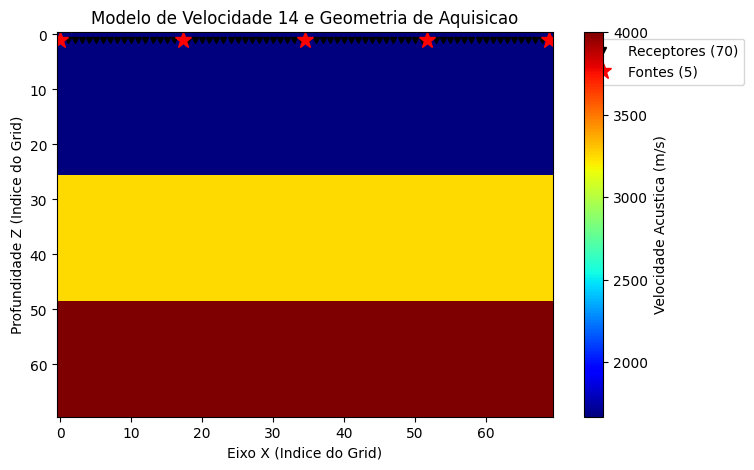

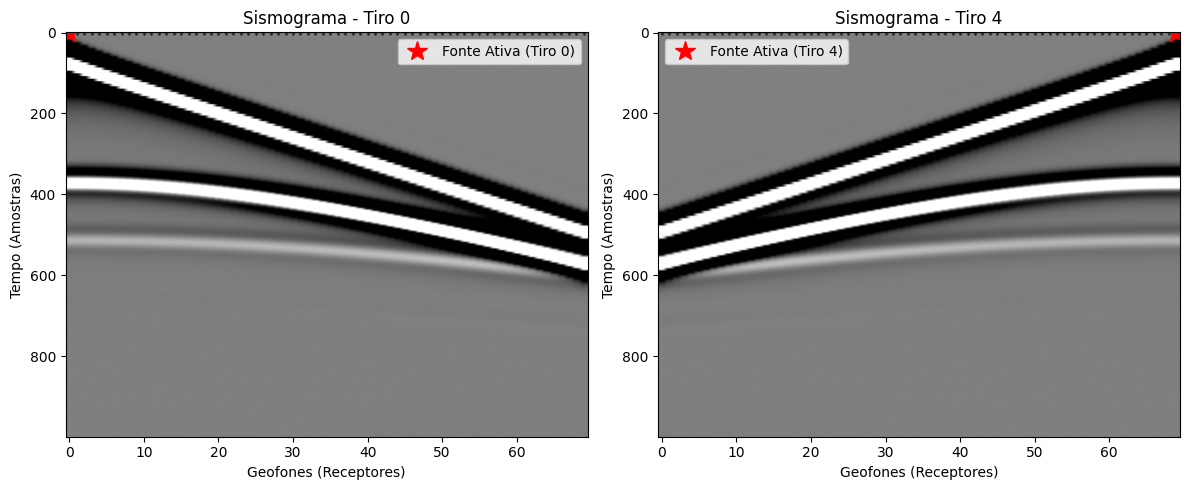

In [21]:
# ==============================================================================
# CELULA 13: VISUALIZACAO EXPLORATORIA DA FISICA (SANITY CHECK)
# ==============================================================================
print("[Visualizacao] Desenhando Modelo Verdadeiro e Sismogramas (OpenFWI)...")

plt.figure(figsize=(8, 5))
img_vel = plt.imshow(true_velocity, cmap='jet', aspect='auto')

# Geofones
rec_x = np.arange(NUM_REC)
rec_z = np.ones(NUM_REC) * 1  
plt.plot(rec_x, rec_z, 'kv', markersize=4, label='Receptores (70)')

# Tiros
shot_x = np.linspace(0, NX-1, NUM_SHOTS)
shot_z = np.ones(NUM_SHOTS) * 1
plt.plot(shot_x, shot_z, 'r*', markersize=12, label='Fontes (5)')

plt.colorbar(img_vel, label='Velocidade Acustica (m/s)')
plt.title('Modelo de Velocidade 14 e Geometria de Aquisicao')
plt.xlabel('Eixo X (Indice do Grid)')
plt.ylabel('Profundidade Z (Indice do Grid)')
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.0))
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Sismograma Tiro 0
shot_0 = seismic_obs[0, :, :]
ax[0].imshow(shot_0, cmap='gray', aspect='auto', vmin=-0.5, vmax=0.5)
ax[0].plot(rec_x, np.zeros(NUM_REC), 'kv', markersize=3, alpha=0.5)
ax[0].plot(0, 0, 'r*', markersize=15, label='Fonte Ativa (Tiro 0)') 
ax[0].set_title('Sismograma - Tiro 0')
ax[0].set_ylabel('Tempo (Amostras)')
ax[0].set_xlabel('Geofones (Receptores)')
ax[0].legend(loc='upper right')

# Sismograma Tiro 4
shot_4 = seismic_obs[4, :, :]
ax[1].imshow(shot_4, cmap='gray', aspect='auto', vmin=-0.5, vmax=0.5)
ax[1].plot(rec_x, np.zeros(NUM_REC), 'kv', markersize=3, alpha=0.5)
ax[1].plot(69, 0, 'r*', markersize=15, label='Fonte Ativa (Tiro 4)') 
ax[1].set_title('Sismograma - Tiro 4')
ax[1].set_ylabel('Tempo (Amostras)')
ax[1].set_xlabel('Geofones (Receptores)')
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [22]:
# ==============================================================================
# CELULA 14: ENGENHARIA DE DADOS - NUVEM DE PONTOS E GEOMETRIA DAS FONTES
# ==============================================================================
print("[Data Engineering] Iniciando transformacao: Grid -> Nuvem de Pontos...")

# Mapeamento Fisico das Fontes Sismicas (Injecao no termo fonte da PDE)
espacamento_tiros = (NX - 1) * DX / (NUM_SHOTS - 1)
posicoes_fontes = [] 

for i in range(NUM_SHOTS):
    x_s = i * espacamento_tiros
    z_s = 10.0  
    posicoes_fontes.append((x_s, z_s))

print(f"Coordenadas das {NUM_SHOTS} fontes calculadas: {posicoes_fontes}")

class SeismicDataDataset(Dataset):
    """
    Transforma a matriz discreta de sismogramas num dominio continuo de pontos fisicos.
    """
    def __init__(self, d_obs: np.ndarray):
        super().__init__()
        
        # 1. Vetores Fisicos
        x_rec = np.arange(NUM_REC) * DX
        z_rec = np.array([10.0])
        t_vec = np.arange(NT) * DT
        
        # 2. Malha Continua (Meshgrid)
        T, Z, X = np.meshgrid(t_vec, z_rec, x_rec, indexing='ij')
        
        # 3. Conversao para Tensores 1D
        self.t_data = torch.tensor(T.flatten(), dtype=torch.float32)
        self.z_data = torch.tensor(Z.flatten(), dtype=torch.float32)
        self.x_data = torch.tensor(X.flatten(), dtype=torch.float32)
        
        # 4. Target (Amplitudes)
        u_reshaped = np.zeros((len(self.t_data), NUM_SHOTS))
        for i in range(NUM_SHOTS):
            u_reshaped[:, i] = d_obs[i, :, :].flatten()
        self.u_data = torch.tensor(u_reshaped, dtype=torch.float32)

        # 5. Normalizacao Topologica [-1, 1]
        self.x_norm = self.normalize(self.x_data, 0.0, (NX-1)*DX)
        self.z_norm = self.normalize(self.z_data, 0.0, (NZ-1)*DX)
        self.t_norm = self.normalize(self.t_data, 0.0, (NT-1)*DT)

    def normalize(self, tensor: torch.Tensor, min_val: float, max_val: float) -> torch.Tensor:
        """Aplica escalonamento Min-Max."""
        return 2.0 * ((tensor - min_val) / (max_val - min_val)) - 1.0

    def __len__(self) -> int:
        return len(self.x_data)

    def __getitem__(self, idx: int) -> Tuple[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor]:
        return (self.x_norm[idx], self.z_norm[idx], self.t_norm[idx]), self.u_data[idx]

dataset_obs = SeismicDataDataset(seismic_obs)
print(f"Volume do Dataset: {len(dataset_obs)} pontos tensores.")

[Data Engineering] Iniciando transformacao: Grid -> Nuvem de Pontos...
Coordenadas das 5 fontes calculadas: [(0.0, 10.0), (172.5, 10.0), (345.0, 10.0), (517.5, 10.0), (690.0, 10.0)]
Volume do Dataset: 70000 pontos tensores.


In [23]:
# ==============================================================================
# CELULA 15: ARQUITETURA DA REDE NEURAL (MULTI-LAYER PERCEPTRON - MLP)
# ==============================================================================
class PINN_MLP(nn.Module):
    """
    Arquitetura de Rede Neural Densa adaptada para Inversao FWI Continua.
    """
    def __init__(self, in_features=3, out_features=5, hidden_layers=6, hidden_neurons=128):
        super().__init__() 
        self.layers = nn.ModuleList()
        
        # Input Layer
        self.layers.append(nn.Linear(in_features, hidden_neurons))
        
        # Hidden Layers
        for _ in range(hidden_layers):
            self.layers.append(nn.Linear(hidden_neurons, hidden_neurons))
            
        # Output Layer
        self.layers.append(nn.Linear(hidden_neurons, out_features))
        
    def forward(self, x_in: torch.Tensor, z_in: torch.Tensor, t_in: torch.Tensor) -> torch.Tensor:
        u = torch.cat([x_in, z_in, t_in], dim=-1)
        
        for i in range(len(self.layers) - 1):
            u = self.layers[i](u)
            u = torch.tanh(u)
            
        u = self.layers[-1](u)
        return u

print("[Arquitetura] Instanciando a PINN (Physics-Informed Neural Network)...")
model_pinn = PINN_MLP(in_features=3, out_features=NUM_SHOTS, hidden_layers=6, hidden_neurons=128)
model_pinn = model_pinn.to(device)
print(model_pinn)

[Arquitetura] Instanciando a PINN (Physics-Informed Neural Network)...
PINN_MLP(
  (layers): ModuleList(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1-6): 6 x Linear(in_features=128, out_features=128, bias=True)
    (7): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [24]:
# ==============================================================================
# CELULA 16: O MOTOR DA FISICA (DERIVADAS AUTOMATICAS E CALCULO DA PDE)
# ==============================================================================
def get_gradient(output: torch.Tensor, input_var: torch.Tensor) -> torch.Tensor:
    """
    Calcula derivadas parciais exatas utilizando a engine Autograd.
    """
    grad_outputs = torch.ones_like(output)
    gradient = torch.autograd.grad(
        outputs=output,
        inputs=input_var,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True
    )[0] 
    
    return gradient

def compute_physics_loss(
    model: nn.Module, 
    x: torch.Tensor, 
    z: torch.Tensor, 
    t: torch.Tensor, 
    c_velocity: torch.Tensor, 
    source_pos: tuple
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Avalia o residuo da Equacao Diferencial Parcial (Onda Acustica Escalar).
    """
    x.requires_grad_(True)
    z.requires_grad_(True)
    t.requires_grad_(True)
    
    u_pred = model(x, z, t) 
    
    # Derivadas Espaciais
    u_x = get_gradient(u_pred, x)  
    u_xx = get_gradient(u_x, x)    
    
    u_z = get_gradient(u_pred, z)  
    u_zz = get_gradient(u_z, z)    
    
    # Derivadas Temporais
    u_t = get_gradient(u_pred, t)  
    u_tt = get_gradient(u_t, t)    
    
    # Residuo Fisico (Loss PDE)
    F_source = 0.0 
    pde_residual = u_tt - (c_velocity ** 2) * (u_xx + u_zz) - F_source
    
    loss_pde = torch.mean(pde_residual ** 2)
    
    return loss_pde, u_pred

print("[MLOps] Motor de Derivacao Automatica e Avaliacao PDE alocados em memoria.")

[MLOps] Motor de Derivacao Automatica e Avaliacao PDE alocados em memoria.
